# Task 2.3 — Evaluation and Results

**Paper:** *Analysis of SVM with Indefinite Kernels* (NIPS 2009)

---

This notebook evaluates the reproduced model from Task 2.2 using:
- Accuracy metrics
- Confusion matrix
- Kernel eigenvalue analysis
- Classification boundary visualization

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.linalg import eigh
from matplotlib.colors import ListedColormap

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [4]:
# ===== Reproduce model from task_2_2 (self-contained) =====

# Load dataset
iris = load_iris()
mask = iris.target >= 1
X = iris.data[mask]
y = np.where(iris.target[mask] == 1, -1, 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Helper functions
def rbf_kernel(X, Y=None, gamma=0.5):
    if Y is None: Y = X
    sq_X = np.sum(X**2, axis=1).reshape(-1, 1)
    sq_Y = np.sum(Y**2, axis=1).reshape(1, -1)
    dist_sq = np.maximum(sq_X + sq_Y - 2*X@Y.T, 0)
    return np.exp(-gamma * dist_sq)

def make_indefinite_kernel(K, noise_level=0.3, seed=42):
    rng = np.random.RandomState(seed)
    R = rng.randn(K.shape[0], K.shape[0])
    N = (R + R.T) / 2.0
    return K + noise_level * N

def project_to_psd(K):
    eigenvalues, Q = eigh(K)
    eigenvalues_clipped = np.maximum(eigenvalues, 0)
    K_psd = Q @ np.diag(eigenvalues_clipped) @ Q.T
    return (K_psd + K_psd.T) / 2.0, eigenvalues, eigenvalues_clipped

# Build kernels
gamma = 0.5
K_psd = rbf_kernel(X_train, gamma=gamma)
K_indef = make_indefinite_kernel(K_psd, noise_level=0.3)
K_projected, eig_orig, eig_clipped = project_to_psd(K_indef)

# Train simplified projected gradient SVM
C = 1.0
n = X_train.shape[0]
Y = np.outer(y_train, y_train)
K_tilde = Y * K_projected
L = np.max(np.abs(np.linalg.eigvalsh(K_tilde)))
step_size = 1.0 / L

alpha = np.zeros(n)
convergence_history = []
for t in range(2000):
    grad = -np.ones(n) + K_tilde @ alpha
    alpha_new = np.clip(alpha - step_size * grad, 0, C)
    obj = -np.sum(alpha_new) + 0.5 * alpha_new @ K_tilde @ alpha_new
    convergence_history.append(obj)
    if np.linalg.norm(alpha_new - alpha) < 1e-6:
        print(f'Converged at iteration {t+1}')
        break
    alpha = alpha_new

# Compute bias
sv_mask = alpha > 1e-5
free_sv_mask = (alpha > 1e-5) & (alpha < C - 1e-5)
if np.sum(free_sv_mask) > 0:
    b = np.mean(y_train[free_sv_mask] - (alpha * y_train) @ K_projected[free_sv_mask].T)
else:
    b = 0

# Predict
def predict(X_new):
    K_test = rbf_kernel(X_train, X_new, gamma=gamma)
    decision = (alpha * y_train) @ K_test + b
    preds = np.sign(decision)
    preds[preds == 0] = 1
    return preds

y_pred_train = predict(X_train)
y_pred_test = predict(X_test)

print(f'Training accuracy: {accuracy_score(y_train, y_pred_train):.4f}')
print(f'Test accuracy:     {accuracy_score(y_test, y_pred_test):.4f}')

Converged at iteration 1213
Training accuracy: 0.9625
Test accuracy:     0.8000


---

## 1. Classification Metrics

In [5]:
# Detailed classification report
print('='*60)
print('Classification Report — Test Set')
print('='*60)
print(classification_report(y_test, y_pred_test, 
                            target_names=['Versicolour (-1)', 'Virginica (+1)']))

print(f'\nOverall Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}')

Classification Report — Test Set
                  precision    recall  f1-score   support

Versicolour (-1)       0.75      0.90      0.82        10
  Virginica (+1)       0.88      0.70      0.78        10

        accuracy                           0.80        20
       macro avg       0.81      0.80      0.80        20
    weighted avg       0.81      0.80      0.80        20


Overall Test Accuracy: 0.8000


---

## 2. Confusion Matrix

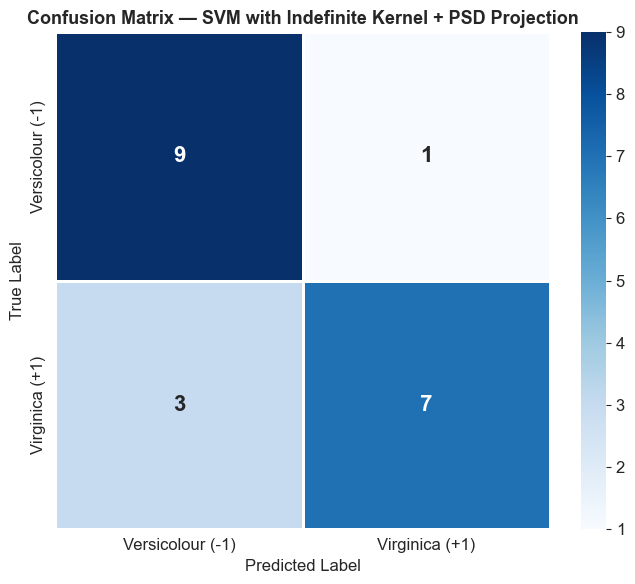

Saved: results/confusion_matrix.png


In [6]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Versicolour (-1)', 'Virginica (+1)'],
            yticklabels=['Versicolour (-1)', 'Virginica (+1)'],
            linewidths=1, linecolor='white', ax=ax,
            annot_kws={'size': 16, 'fontweight': 'bold'})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — SVM with Indefinite Kernel + PSD Projection', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/confusion_matrix.png')

---

## 3. Kernel Eigenvalue Analysis

Visualize how the PSD projection modifies the eigenvalue spectrum of the kernel matrix.

**Ref:** Proposition 1 — negative eigenvalues are clipped to zero.

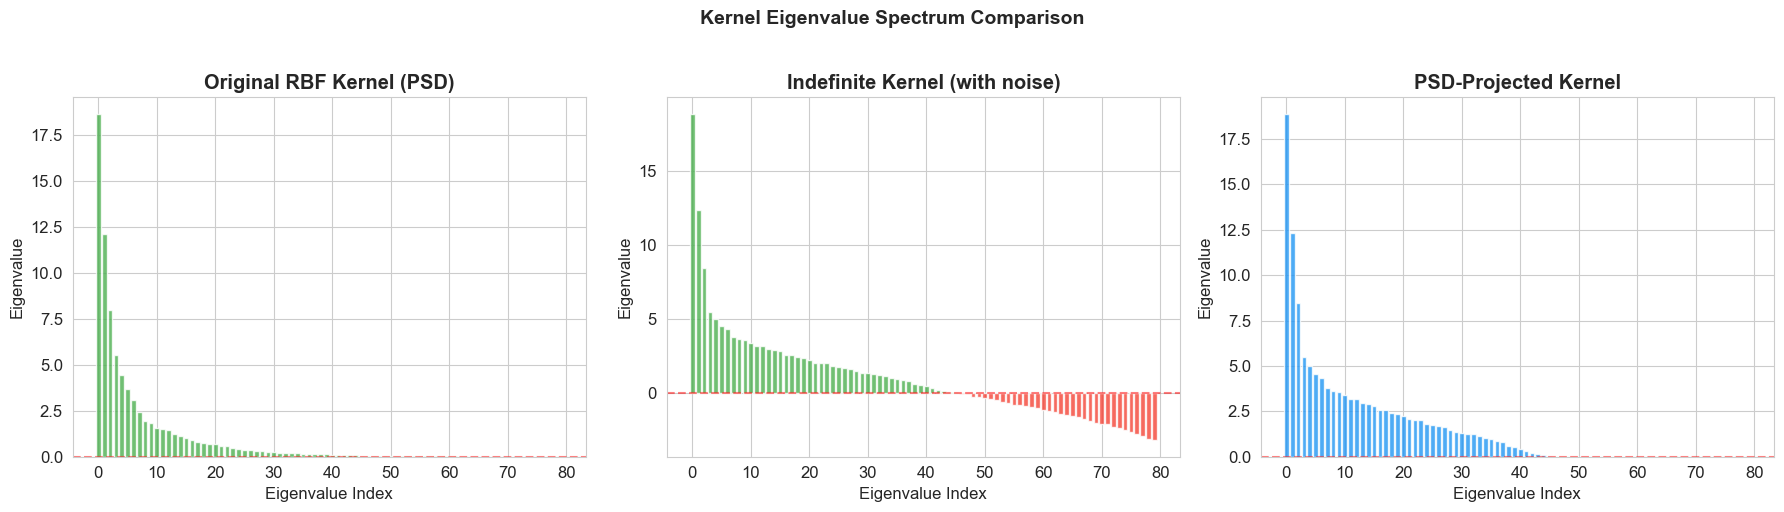

Saved: results/kernel_eigenvalues.png


In [7]:
# Eigenvalue comparison plot
eig_psd_orig = np.linalg.eigvalsh(K_psd)
eig_indef = np.linalg.eigvalsh(K_indef)
eig_proj = np.linalg.eigvalsh(K_projected)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original PSD kernel eigenvalues
axes[0].bar(range(len(eig_psd_orig)), np.sort(eig_psd_orig)[::-1], 
            color='#4CAF50', alpha=0.8, edgecolor='white')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Original RBF Kernel (PSD)', fontweight='bold')
axes[0].set_xlabel('Eigenvalue Index')
axes[0].set_ylabel('Eigenvalue')

# Indefinite kernel eigenvalues
colors_indef = ['#F44336' if v < 0 else '#4CAF50' for v in np.sort(eig_indef)[::-1]]
axes[1].bar(range(len(eig_indef)), np.sort(eig_indef)[::-1], 
            color=colors_indef, alpha=0.8, edgecolor='white')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Indefinite Kernel (with noise)', fontweight='bold')
axes[1].set_xlabel('Eigenvalue Index')
axes[1].set_ylabel('Eigenvalue')

# Projected kernel eigenvalues
axes[2].bar(range(len(eig_proj)), np.sort(eig_proj)[::-1], 
            color='#2196F3', alpha=0.8, edgecolor='white')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('PSD-Projected Kernel', fontweight='bold')
axes[2].set_xlabel('Eigenvalue Index')
axes[2].set_ylabel('Eigenvalue')

plt.suptitle('Kernel Eigenvalue Spectrum Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/kernel_eigenvalues.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/kernel_eigenvalues.png')

---

## 4. Classification Boundary Visualization

Plot the decision boundary using the first two features.

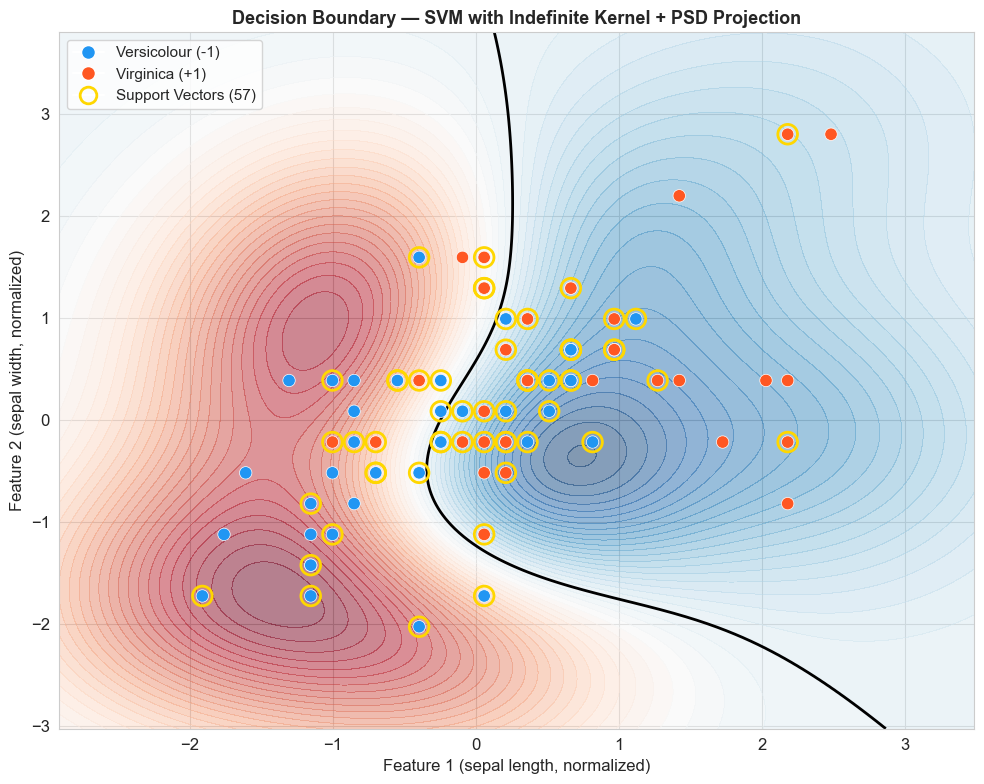

Saved: results/decision_boundary.png


In [8]:
# Decision boundary using first 2 features
# Retrain model using only first 2 features for visualization
X_train_2d = X_train[:, :2]
X_test_2d = X_test[:, :2]

# Recompute kernel with 2D data
K_psd_2d = rbf_kernel(X_train_2d, gamma=gamma)
K_indef_2d = make_indefinite_kernel(K_psd_2d, noise_level=0.3)
K_proj_2d, _, _ = project_to_psd(K_indef_2d)

# Train
Y_2d = np.outer(y_train, y_train)
K_tilde_2d = Y_2d * K_proj_2d
L_2d = np.max(np.abs(np.linalg.eigvalsh(K_tilde_2d)))
alpha_2d = np.zeros(n)
for t in range(2000):
    grad = -np.ones(n) + K_tilde_2d @ alpha_2d
    alpha_new = np.clip(alpha_2d - (1/L_2d) * grad, 0, C)
    if np.linalg.norm(alpha_new - alpha_2d) < 1e-6:
        break
    alpha_2d = alpha_new

free_sv = (alpha_2d > 1e-5) & (alpha_2d < C - 1e-5)
if np.sum(free_sv) > 0:
    b_2d = np.mean(y_train[free_sv] - (alpha_2d * y_train) @ K_proj_2d[free_sv].T)
else:
    b_2d = 0

# Create mesh grid for decision boundary
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Decision function on grid
K_grid = rbf_kernel(X_train_2d, grid, gamma=gamma)
Z = (alpha_2d * y_train) @ K_grid + b_2d
Z = Z.reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Decision boundary
ax.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.5)
ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)

# Data points
colors = np.where(y_train == -1, '#2196F3', '#FF5722')
ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=colors, 
           edgecolors='white', s=80, zorder=5, linewidth=0.5)

# Support vectors
sv_2d = alpha_2d > 1e-5
ax.scatter(X_train_2d[sv_2d, 0], X_train_2d[sv_2d, 1], 
           s=200, facecolors='none', edgecolors='gold', linewidths=2, 
           label=f'Support Vectors ({np.sum(sv_2d)})', zorder=6)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3', markersize=10, label='Versicolour (-1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF5722', markersize=10, label='Virginica (+1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='gold', 
           markersize=12, markeredgewidth=2, label=f'Support Vectors ({np.sum(sv_2d)})'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)

ax.set_xlabel('Feature 1 (sepal length, normalized)', fontsize=12)
ax.set_ylabel('Feature 2 (sepal width, normalized)', fontsize=12)
ax.set_title('Decision Boundary — SVM with Indefinite Kernel + PSD Projection',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('results/decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/decision_boundary.png')

---

## 5. Reproducibility Checklist

| Item | Status |
|------|--------|
| Random seed set (42) | ✅ |
| Dataset source specified (Iris) | ✅ |
| Preprocessing documented (StandardScaler) | ✅ |
| Train/test split documented (80/20 stratified) | ✅ |
| Hyperparameters stated (C=1.0, γ=0.5, noise=0.3) | ✅ |
| Algorithm steps reference paper equations | ✅ |
| Results saved to `results/` directory | ✅ |
| Code is self-contained and runnable | ✅ |
| Dependencies listed in requirements.txt | ✅ |
| All libraries CPU-compatible | ✅ |